# 파라미터를 바꾸어 강화학습을 보완

기존 naive한 모델은 높은 보상을 받지 못함. 따라서 보완함.

1. num_episodes = 500
2. epsilon_decay = 0.99
3. learning rate = 0.0005
4. 초기 Replay Buffer 경험 1000개 저장
5. target_net은 10 에피소드마다 업데이트

In [59]:
# 라이브러리 불러오기
import random
from collections import deque

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym

In [60]:
# device 설정
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("사용 device:", device)

사용 device: mps


In [61]:
# CartPole 환경 생성
env = gym.make("CartPole-v1")

state, info = env.reset(seed=42)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print("state_dim:", state_dim)
print("action_dim:", action_dim)

state_dim: 4
action_dim: 2


In [62]:
# DQN 모델 정의
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)

In [63]:
# Replay Buffer 구현
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)

        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.tensor(np.array(states), dtype=torch.float32).to(device)
        actions = torch.tensor(actions, dtype=torch.long).unsqueeze(1).to(device)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(device)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32).to(device)
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1).to(device)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

In [64]:
# 모델, 손실 함수, 옵티마이저 설정
policy_net = DQN(state_dim, action_dim).to(device)

target_net = DQN(state_dim, action_dim).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

criterion = nn.MSELoss()
optimizer = optim.Adam(policy_net.parameters(), lr=0.0005)

replay_buffer = ReplayBuffer(capacity=10000)

gamma = 0.99
batch_size = 64

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.99

num_episodes = 500
target_update = 10

print(policy_net)

DQN(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [65]:
# epsilon-greedy 행동 선택 함수
def select_action(state, epsilon):
    if random.random() < epsilon:
        action = env.action_space.sample()
    else:
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            q_values = policy_net(state_tensor)

        action = q_values.argmax(dim=1).item()

    return action

In [66]:
# 초기 랜덤 경험 1000개 저장
state, info = env.reset(seed=42)

for step in range(1000):
    action = env.action_space.sample()

    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    replay_buffer.push(state, action, reward, next_state, done)

    state = next_state

    if done:
        state, info = env.reset()

print("초기 Replay Buffer 크기:", len(replay_buffer))

초기 Replay Buffer 크기: 1000


In [67]:
# DQN 학습 함수
def train_step():
    if len(replay_buffer) < batch_size:
        return None

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    current_q_values = policy_net(states).gather(1, actions)

    with torch.no_grad():
        next_q_values = target_net(next_states).max(dim=1, keepdim=True)[0]
        target_q_values = rewards + gamma * next_q_values * (1 - dones)

    loss = criterion(current_q_values, target_q_values)

    optimizer.zero_grad()
    loss.backward()

    # 기울기가 너무 커지는 것을 방지
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=1.0)

    optimizer.step()

    return loss.item()

In [68]:
# DQN 학습 루프
episode_rewards = []
episode_steps = []
losses = []
improved_avg_reward = -float("inf")

for episode in range(num_episodes):
    state, info = env.reset()
    total_reward = 0
    done = False

    while not done:
        action = select_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        replay_buffer.push(state, action, reward, next_state, done)

        loss = train_step()

        if loss is not None:
            losses.append(loss)

        state = next_state
        total_reward += reward

    episode_rewards.append(total_reward)

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if (episode + 1) % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if (episode + 1) % 10 == 0:
        recent_avg_reward = np.mean(episode_rewards[-10:])

        if recent_avg_reward > improved_avg_reward:
            improved_avg_reward = recent_avg_reward
            torch.save(policy_net.state_dict(), "./models/improved_dqn_model.pt")

        print(
            f"Episode {episode + 1}, "
            f"Average Reward: {recent_avg_reward:.2f}, "
            f"improved Average Reward: {improved_avg_reward:.2f}, "
            f"Epsilon: {epsilon:.4f}, "
            f"Replay Buffer: {len(replay_buffer)}"
        )

Episode 10, Average Reward: 19.70, improved Average Reward: 19.70, Epsilon: 0.9044, Replay Buffer: 1197
Episode 20, Average Reward: 19.10, improved Average Reward: 19.70, Epsilon: 0.8179, Replay Buffer: 1388
Episode 30, Average Reward: 21.90, improved Average Reward: 21.90, Epsilon: 0.7397, Replay Buffer: 1607
Episode 40, Average Reward: 31.90, improved Average Reward: 31.90, Epsilon: 0.6690, Replay Buffer: 1926
Episode 50, Average Reward: 48.20, improved Average Reward: 48.20, Epsilon: 0.6050, Replay Buffer: 2408
Episode 60, Average Reward: 70.50, improved Average Reward: 70.50, Epsilon: 0.5472, Replay Buffer: 3113
Episode 70, Average Reward: 103.80, improved Average Reward: 103.80, Epsilon: 0.4948, Replay Buffer: 4151
Episode 80, Average Reward: 100.80, improved Average Reward: 103.80, Epsilon: 0.4475, Replay Buffer: 5159
Episode 90, Average Reward: 142.90, improved Average Reward: 142.90, Epsilon: 0.4047, Replay Buffer: 6588
Episode 100, Average Reward: 170.20, improved Average Rewa

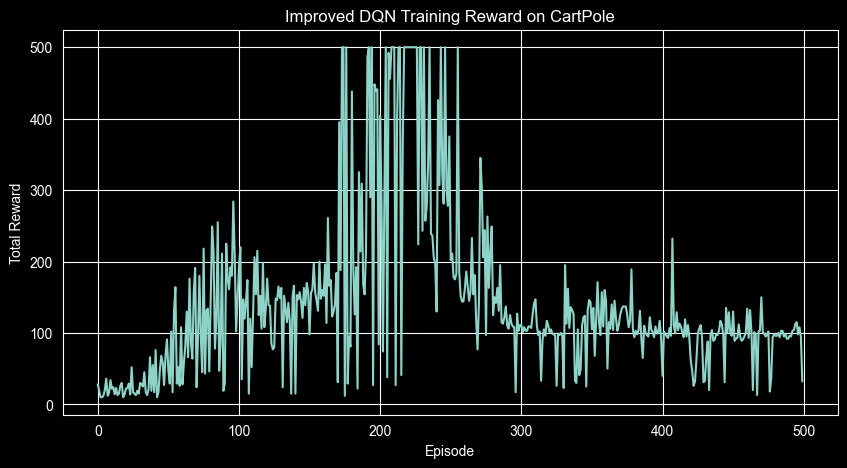

In [69]:
# 에피소드별 누적 보상 그래프
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Improved DQN Training Reward on CartPole")
plt.show()

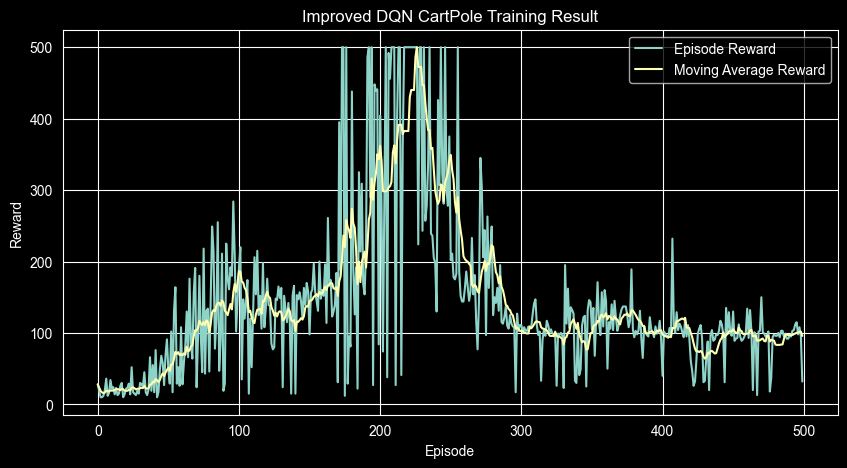

In [70]:
# 최근 10개 에피소드 평균 보상 그래프
moving_avg = []

for i in range(len(episode_rewards)):
    recent_rewards = episode_rewards[max(0, i - 9):i + 1]
    moving_avg.append(np.mean(recent_rewards))

plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, label="Episode Reward")
plt.plot(moving_avg, label="Moving Average Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Improved DQN CartPole Training Result")
plt.legend()
plt.show()

In [71]:
# 학습 후 최종 결과 확인
print("마지막 10개 에피소드 평균 보상:", np.mean(episode_rewards[-10:]))
print("최고 에피소드 보상:", max(episode_rewards))
print("최종 epsilon:", epsilon)
print("최종 Replay Buffer 크기:", len(replay_buffer))

마지막 10개 에피소드 평균 보상: 95.8
최고 에피소드 보상: 500.0
최종 epsilon: 0.05
최종 Replay Buffer 크기: 10000


1. 같은 구조의 DQN 모델을 새로 만든다.
2. 저장된 가중치 improved_dqn_cartpole.pt를 불러온다.
3. 모델을 eval 모드로 바꾼다.
4. epsilon 없이 Q-value가 가장 큰 행동만 선택해서 테스트한다.
5. 여러 에피소드의 평균 보상을 확인한다.

In [72]:
# 저장된 improved DQN 모델 로드
improved_model = DQN(state_dim, action_dim).to(device)

improved_model.load_state_dict(
    torch.load("./models/improved_dqn_model.pt", map_location=device)
)

improved_model.eval()

print("improved_dqn_model.pt 로드 완료")

improved_dqn_model.pt 로드 완료


In [75]:
# improved 모델로 행동 선택
def select_improved_action(state):
    state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        q_values = improved_model(state_tensor)

    action = q_values.argmax(dim=1).item()

    return action

In [76]:
# improved 모델 테스트
test_episodes = 20
test_rewards = []

for episode in range(test_episodes):
    state, info = env.reset()
    total_reward = 0
    done = False

    while not done:
        action = select_improved_action(state)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        state = next_state
        total_reward += reward

    test_rewards.append(total_reward)

print("테스트 에피소드별 보상:", test_rewards)
print("평균 테스트 보상:", np.mean(test_rewards))
print("최고 테스트 보상:", max(test_rewards))
print("최저 테스트 보상:", min(test_rewards))

테스트 에피소드별 보상: [500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0]
평균 테스트 보상: 500.0
최고 테스트 보상: 500.0
최저 테스트 보상: 500.0


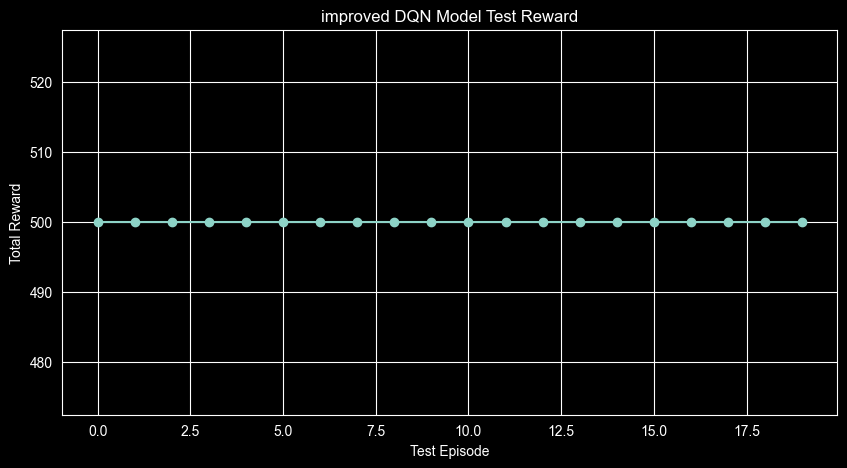

In [77]:
# improved 모델 테스트 보상 그래프
plt.figure(figsize=(10, 5))
plt.plot(test_rewards, marker="o")
plt.xlabel("Test Episode")
plt.ylabel("Total Reward")
plt.title("improved DQN Model Test Reward")
plt.show()

In [78]:
from matplotlib import animation
from IPython.display import HTML

render_env = gym.make("CartPole-v1", render_mode="rgb_array")

state, info = render_env.reset(seed=42)
frames = []
total_reward = 0
done = False

while not done:
    frame = render_env.render()
    frames.append(frame)

    action = select_improved_action(state)

    next_state, reward, terminated, truncated, info = render_env.step(action)
    done = terminated or truncated

    state = next_state
    total_reward += reward

render_env.close()

print("애니메이션 에피소드 보상:", total_reward)
print("저장된 frame 수:", len(frames))

fig = plt.figure(figsize=(6, 4))
plt.axis("off")
img = plt.imshow(frames[0])

def update(frame):
    img.set_data(frame)
    return [img]

ani = animation.FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=30,
    blit=True
)

plt.close(fig)
HTML(ani.to_jshtml())

애니메이션 에피소드 보상: 500.0
저장된 frame 수: 500
